In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Spring25_Semester/IS_296/IS296_Collab/project

/content/drive/MyDrive/Spring25_Semester/IS_296/IS296_Collab/project


In [ ]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [ ]:
tbl = Table.read_table('Sleep_health_and_lifestyle_dataset.csv')
tbl

Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,nan
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,nan
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,nan
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,nan
9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,nan
10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,nan


In [ ]:
tbl.group('Occupation').show()

Occupation,count
Accountant,37
Doctor,71
Engineer,63
Lawyer,47
Manager,1
Nurse,73
Sales Representative,2
Salesperson,32
Scientist,4
Software Engineer,4


From Mini-Update #1:
### **Q1.** Are doctors and nurses more physically active than non-doctors?

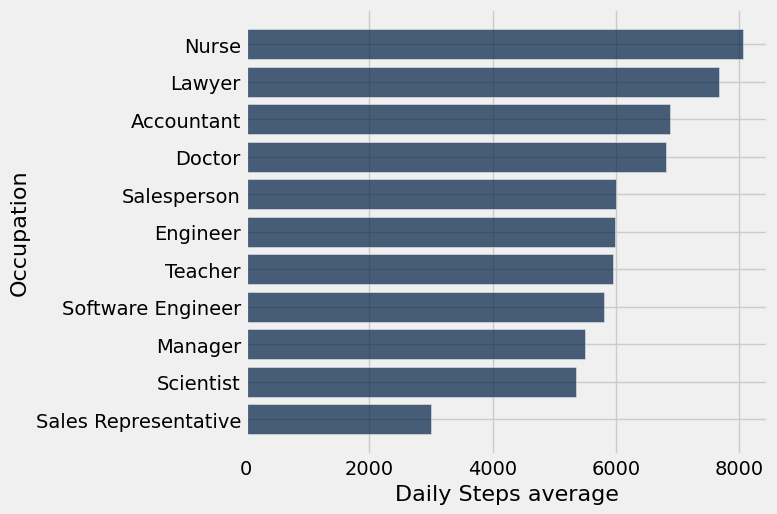

In [ ]:
tbl_40 = tbl.select('Occupation', 'Daily Steps')
tbl_40.group('Occupation', np.average).sort('Daily Steps average', descending=True).barh('Occupation')

In [ ]:
# Created a table that shows data for Doctors and Nurses only
# Used ChatGPT to help me create this function
def occupation_filter(occupation):
    return 'Doctor' in occupation or 'Nurse' in occupation

tbl_doc_nurses = tbl.where('Occupation', occupation_filter)

In [ ]:
# Created a table that shows data for all other occupations
# Used ChatGPT to help me create this function
def not_occupation_filter(occupation):
    return not occupation_filter(occupation)

tbl_others = tbl.where('Occupation', not_occupation_filter)

In [ ]:
# Created new table that shows Physical Activity Level average and Daily Steps average for doctors
phys_doc_nurses = tbl_doc_nurses.select('Occupation', 'Physical Activity Level','Daily Steps').group('Occupation',np.average)
phys_doc_nurses

Occupation,Physical Activity Level average,Daily Steps average
Doctor,55.3521,6808.45
Nurse,78.589,8057.53


In [ ]:
# Created a new table that shows Physical Activity Level average and Daily Steps average for all other occupations
phys_others = tbl_others.select('Occupation', 'Physical Activity Level','Daily Steps')
avg_phys_others = phys_others.group('Occupation',np.average)
avg_phys_others

Occupation,Physical Activity Level average,Daily Steps average
Accountant,58.1081,6881.08
Engineer,51.8571,5980.95
Lawyer,70.4255,7661.7
Manager,55,5500
Sales Representative,30,3000
Salesperson,45,6000
Scientist,41,5350
Software Engineer,48,5800
Teacher,45.625,5957.5


In [ ]:
total_avg_phys = round(np.average(avg_phys_others.column('Physical Activity Level average')), 2)
total_avg_phys

49.450000000000003

In [ ]:
total_avg_steps = round(np.average(avg_phys_others.column('Daily Steps average')), 2)
total_avg_steps

5792.3599999999997

In [ ]:
tbl_all_others = Table().with_columns(
    'Occupation', 'All Others',
    'Physical Activity Level average', total_avg_phys,
    'Daily Steps average', total_avg_steps
)
tbl_all_others

Occupation,Physical Activity Level average,Daily Steps average
All Others,49.45,5792.36


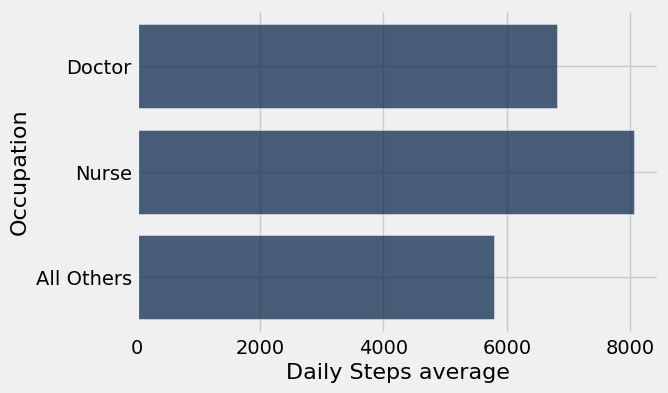

In [ ]:
final_tbl = phys_doc_nurses.with_row(tbl_all_others)
final_tbl.drop('Physical Activity Level average').barh('Occupation')

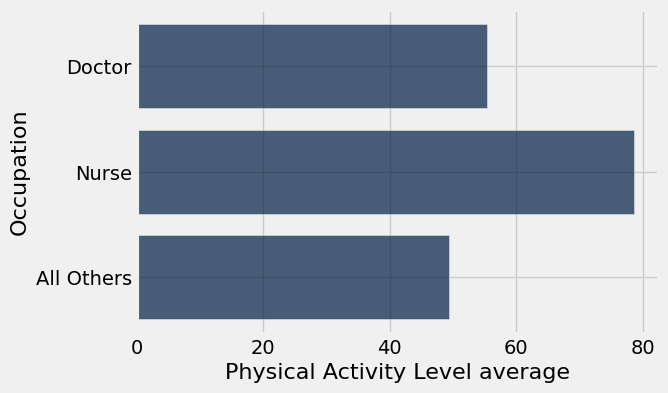

In [ ]:
final_tbl.drop('Daily Steps average').barh('Occupation')

### **New Question:**
### **Q2.** How do the stress levels of doctors and nurses compare to all other occupations?

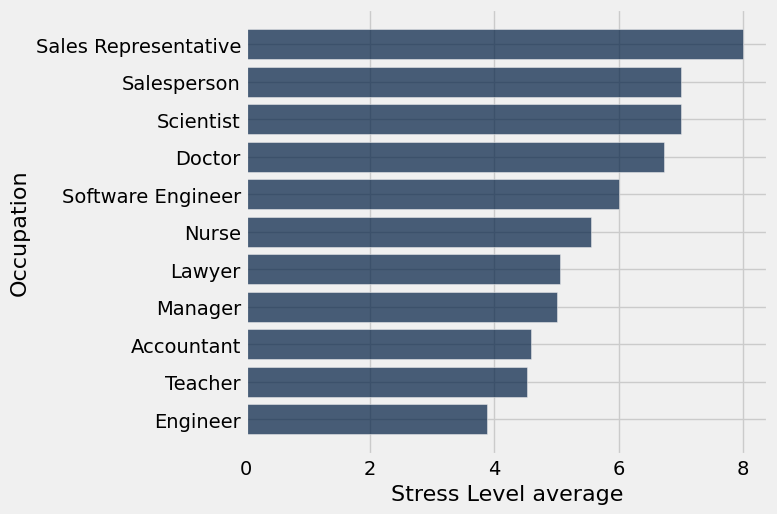

In [ ]:
blah_tbl = tbl.select('Occupation','Stress Level')
blah_tbl.group('Occupation', np.average).sort('Stress Level average', descending=True).barh('Occupation')

In [ ]:
blah_tbl.group('Occupation', np.average).show()

Occupation,Stress Level average
Accountant,4.59459
Doctor,6.73239
Engineer,3.88889
Lawyer,5.06383
Manager,5
Nurse,5.54795
Sales Representative,8
Salesperson,7
Scientist,7
Software Engineer,6


In [ ]:
# Created a table that shows Stress Level average for Doctors and Nurses only
stress_doc_nurses = tbl_doc_nurses.select('Occupation','Stress Level').group('Occupation', np.average)
stress_doc_nurses

Occupation,Stress Level average
Doctor,6.73239
Nurse,5.54795


In [ ]:
# Created a table that shows Stress Level average for all other occupations
stress_others = tbl_others.select('Occupation','Stress Level').group('Occupation', np.average)
avg_stress = round(np.average(stress_others.column('Stress Level average')), 2)
stress_all_others = Table().with_columns(
    'Occupation', 'All Others',
    'Stress Level average', avg_stress,
)
stress_all_others

Occupation,Stress Level average
All Others,5.67


In [ ]:
stress_others

Occupation,Stress Level average
Accountant,4.59459
Engineer,3.88889
Lawyer,5.06383
Manager,5
Sales Representative,8
Salesperson,7
Scientist,7
Software Engineer,6
Teacher,4.525


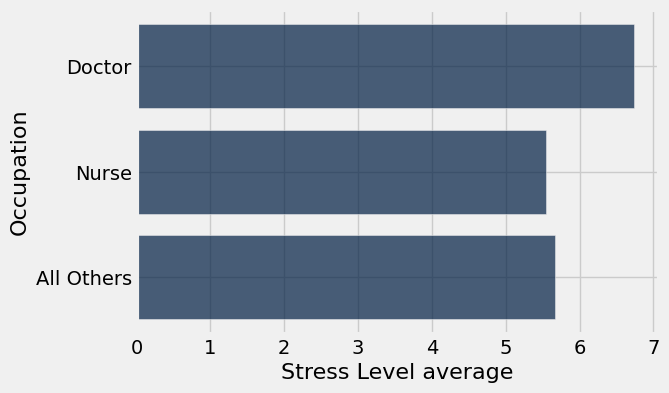

In [ ]:
final_tbl_stress = stress_doc_nurses.with_row(stress_all_others)
final_tbl_stress.barh('Occupation')

From Mini-Update #1:

### **Q3.** Is there any correlation between sleep and BMI category?

In [ ]:
tbl.labels

('Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder')

In [ ]:
tbl.select('BMI Category').group('BMI Category')

BMI Category,count
Normal,195
Normal Weight,21
Obese,10
Overweight,148


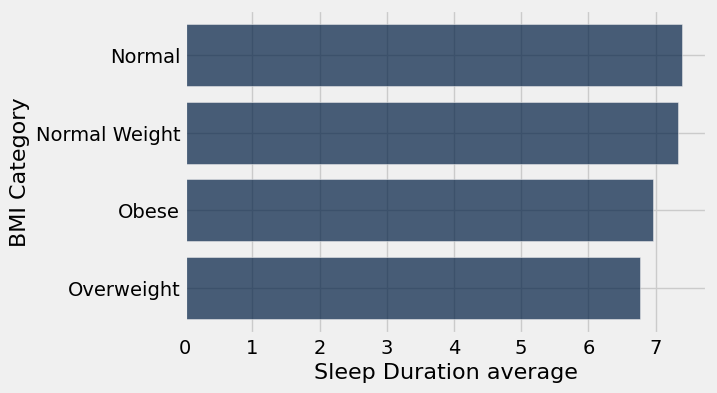

In [ ]:
tbl.select('Sleep Duration', 'BMI Category').group('BMI Category', np.average).barh('BMI Category')

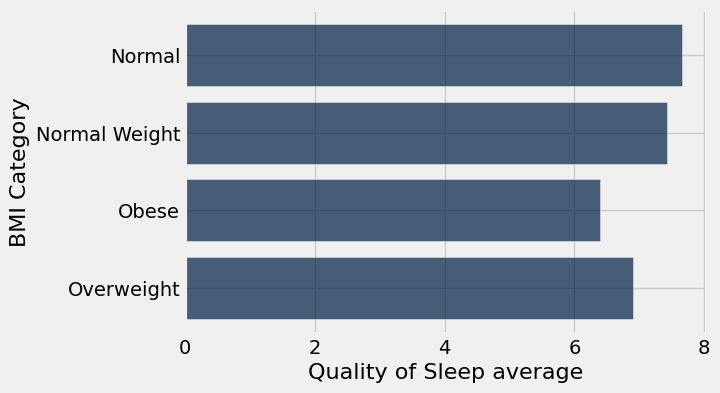

In [ ]:
tbl.select('Quality of Sleep', 'BMI Category').group('BMI Category', np.average).barh('BMI Category')

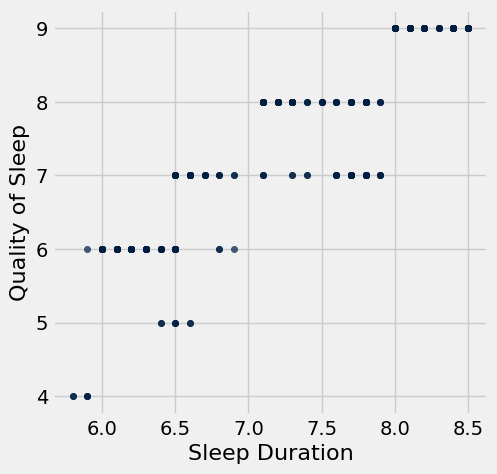

In [ ]:
tbl.select('Sleep Duration', 'Quality of Sleep').scatter('Sleep Duration')

### **New Question:**
### **Q4.** What are the patterns between Occupation and Sleep Duration/Quality of Sleep?

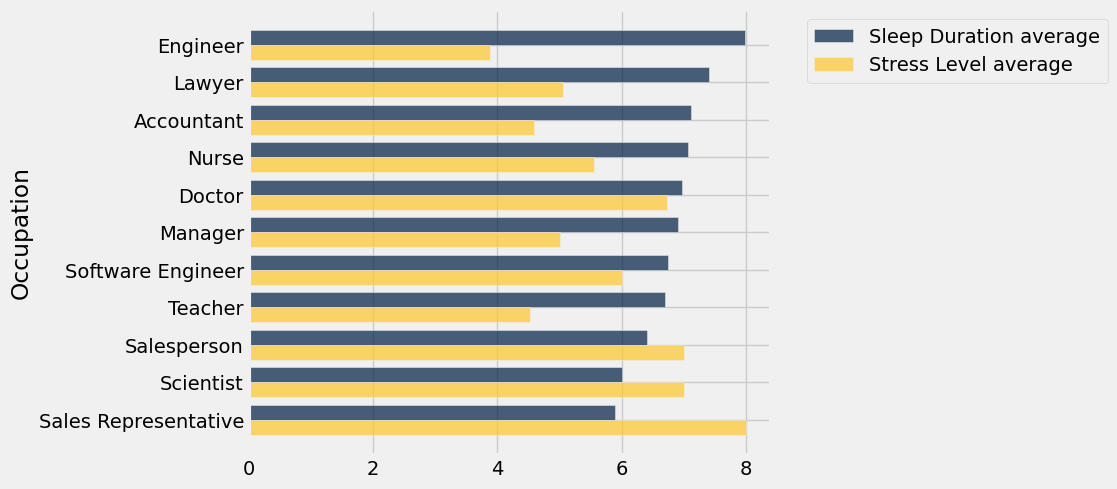

In [ ]:
tbl.select('Occupation', 'Sleep Duration','Stress Level').group('Occupation', np.average).sort('Sleep Duration average', descending=True).barh('Occupation')

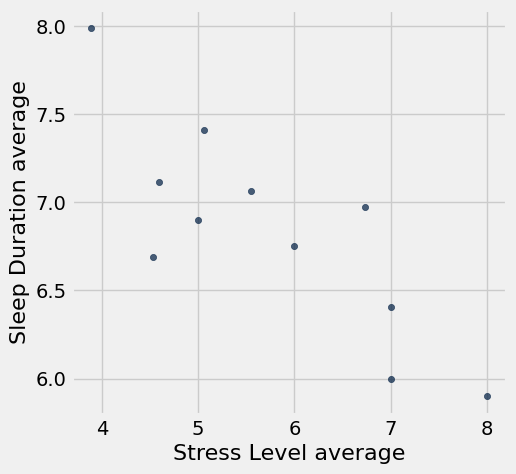

In [ ]:
tbl.select('Occupation', 'Sleep Duration','Stress Level').group('Occupation', np.average).sort('Sleep Duration average', descending=True).drop("Occupation").scatter('Stress Level average')

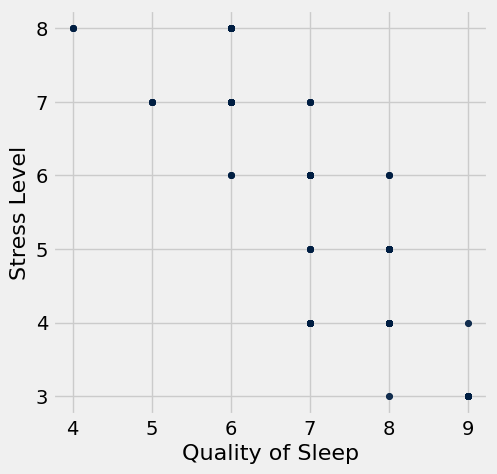

In [ ]:
tbl.scatter('Quality of Sleep', 'Stress Level')

### Permutation Test:

In [ ]:
correlation_matrix = np.corrcoef(tbl.column('Quality of Sleep'),tbl.column('Stress Level'))
correlation_coefficient = correlation_matrix[0, 1]
correlation_coefficient

-0.89875203100404366

In [ ]:
def get_cor(table, var1, var2):
    """
    table: name of table,
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    return: correlation coefficient as a numeric value"""
    correlation_matrix = np.corrcoef(table.column(var1),table.column(var2))
    my_result = correlation_matrix[0, 1]
    return my_result

In [ ]:
observed_correlation = get_cor(tbl,'Quality of Sleep', 'Stress Level') # update
observed_correlation

-0.89875203100404366

In [ ]:
def one_simulated_cor(table, var1, var2):
    """
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    Returns: correlation between two variables after shuffling"""
    shuffled_var2 = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled var2', shuffled_var2)
    return get_cor(shuffled_table, var1, 'Shuffled var2')

In [ ]:
one_simulated_cor(tbl,'Quality of Sleep', 'Stress Level')

0.073147249855360433

In [ ]:
cor_list = make_array()
for i in np.arange(100):
    new_cor = one_simulated_cor(tbl,'Quality of Sleep', 'Stress Level') # update
    cor_list= np.append(cor_list, new_cor)
cor_list

array([  1.40044213e-01,  -2.58516164e-03,   5.29519401e-02,
         4.66409058e-02,  -3.28781262e-02,  -2.58516164e-03,
         1.88723550e-02,   1.38235275e-02,   2.51833892e-02,
        -2.58516164e-03,   5.92629744e-02,   1.76101481e-02,
         3.65432510e-02,  -3.54025400e-02,   1.03440214e-01,
         2.89700098e-02,  -5.55978497e-02,   2.46366579e-03,
         8.77470008e-03,   2.26589755e-02,   5.16897333e-02,
         6.25028637e-03,   9.58669733e-02,  -4.92868154e-02,
         3.40188372e-02,  -1.14206096e-02,   1.20145893e-03,
        -5.93844703e-02,  -2.58516164e-03,  -1.26828165e-02,
        -2.58516164e-03,   6.55740087e-02,  -9.97750897e-02,
         3.78054578e-02,   9.20803527e-02,  -8.89619593e-03,
        -6.37178221e-03,  -1.64694371e-02,  -5.10957536e-03,
        -5.68600565e-02,   1.20145893e-03,   1.25613207e-02,
        -1.07348331e-01,   8.82937322e-02,   4.03298715e-02,
        -3.84736850e-03,   1.76101481e-02,  -2.58516164e-03,
         2.64455961e-02,

Observed correlation: -0.898752031004
p-value= 0.0


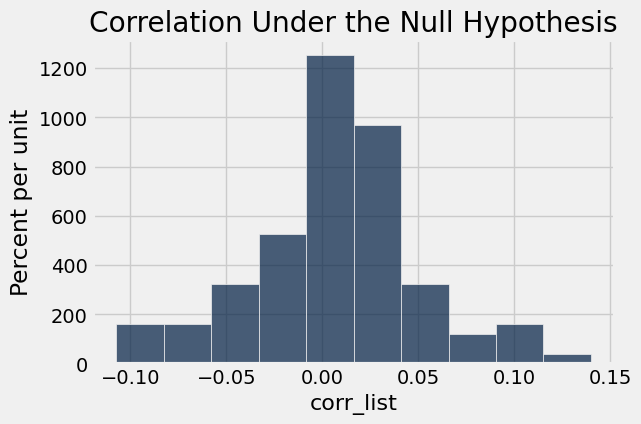

In [ ]:
Table().with_column('corr_list', cor_list).hist()
print('Observed correlation:',observed_correlation)
print('p-value=',np.mean(cor_list<observed_correlation)) # update: change the sign < or > to according to your problem
plots.title('Correlation Under the Null Hypothesis');

### **Q5.** Any correlation between age and stress levels?

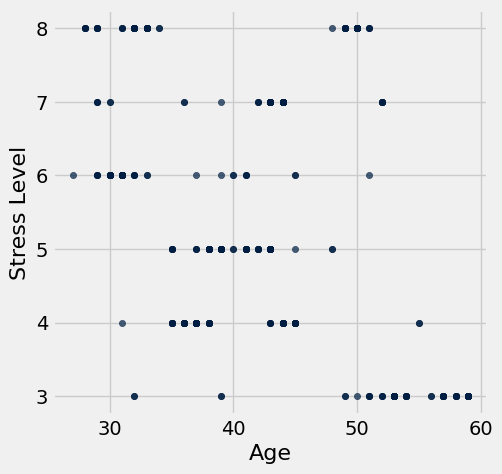

In [ ]:
tbl.select('Stress Level','Age').scatter('Age')

### Permutation Test:

In [ ]:
correlation_matrix = np.corrcoef(tbl.column('Age'),tbl.column('Stress Level'))
correlation_coefficient = correlation_matrix[0, 1]
correlation_coefficient

-0.42234448262025087

In [ ]:
def get_cor(table, var1, var2):
    """
    table: name of table,
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    return: correlation coefficient as a numeric value"""
    correlation_matrix = np.corrcoef(table.column(var1),table.column(var2))
    my_result = correlation_matrix[0, 1]
    return my_result

In [ ]:
def one_simulated_cor(table, var1, var2):
    """
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    Returns: correlation between two variables after shuffling"""
    shuffled_var2 = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled var2', shuffled_var2)
    return get_cor(shuffled_table, var1, 'Shuffled var2')

In [ ]:
one_simulated_cor(tbl,'Age', 'Stress Level')

0.037352923524769668

In [ ]:
cor_list = make_array()
for i in np.arange(100):
    new_cor = one_simulated_cor(tbl,'Age', 'Stress Level') # update
    cor_list= np.append(cor_list, new_cor)
cor_list

array([-0.04364719, -0.01821489,  0.0295142 , -0.03964073,  0.04310132,
        0.01052708, -0.03145362,  0.07254007, -0.05009236,  0.02637871,
        0.001469  ,  0.03386905, -0.05305365,  0.08212073, -0.0291891 ,
        0.00059803, -0.00497617, -0.04747945,  0.10685624,  0.02237226,
        0.13072079,  0.04275293, -0.00236326, -0.03284717, -0.01072456,
        0.05599166, -0.03528589,  0.0183658 ,  0.08874009, -0.00846004,
       -0.03075685, -0.06733754,  0.03979164,  0.01366257, -0.09520855,
       -0.07291174,  0.0660949 ,  0.05407553,  0.04188196,  0.00094642,
       -0.02413748, -0.01368586,  0.01383676, -0.01403424,  0.04989488,
       -0.09555694, -0.05827947, -0.04173106,  0.06191425,  0.01104966,
        0.01575289,  0.04675939, -0.0237891 , -0.00602133, -0.0236149 ,
        0.04101099, -0.0685569 , -0.03528589, -0.0013181 ,  0.02603033,
       -0.04504074,  0.01174644, -0.04469235, -0.01978264,  0.05564327,
        0.08647557,  0.14761759,  0.03648195,  0.01157224, -0.04

Observed correlation: -0.898752031004
p-value= 0.0


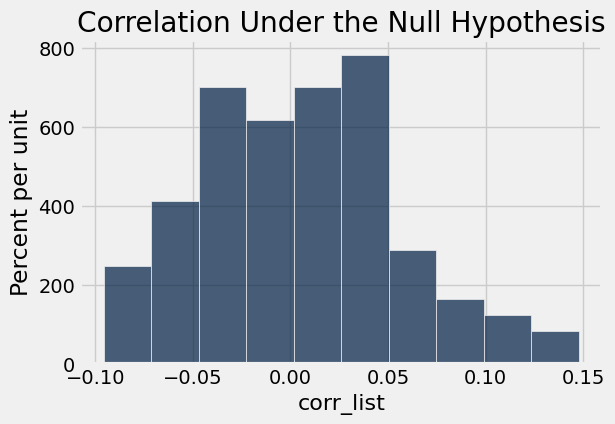

In [ ]:
Table().with_column('corr_list', cor_list).hist()
print('Observed correlation:',observed_correlation)
print('p-value=',np.mean(cor_list<observed_correlation)) # update: change the sign < or > to according to your problem
plots.title('Correlation Under the Null Hypothesis');

### **Q6.** Next data insight involves exploring the gender makeup, ages, and lifestyle habits of Engineers (the least stressed occupation) and Sales Representatives (the most stressed occupation)

In [ ]:
tbl.labels

('Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder')

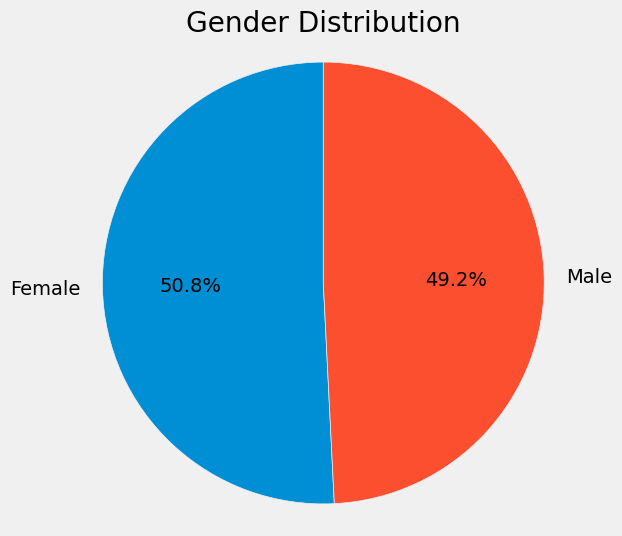

In [ ]:
tbl_engineer = tbl.where('Occupation','Engineer').select('Quality of Sleep','Age','Gender','Stress Level', 'Physical Activity Level','BMI Category','Daily Steps')
pie_tbl = tbl_engineer.group('Gender')
labels = pie_tbl.column('Gender')
sizes  = pie_tbl.column('count')

# Used ChatGPT to help me make this pie chart
plots.figure(figsize=(6,6))
plots.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',   # show percentages
    startangle=90        # rotate so first slice is at 12 o’clock
)
plots.title('Gender Distribution')
plots.axis('equal')        # ensure circle shape
plots.show()

In [82]:
tbl_engineer = tbl.where('Occupation','Engineer').select('Quality of Sleep','Age','Gender','Stress Level', 'Physical Activity Level','BMI Category','Daily Steps')
tbl_engineer.sort('Stress Level')

Quality of Sleep,Age,Gender,Stress Level,Physical Activity Level,BMI Category,Daily Steps
8,32,Male,3,45,Normal,8000
8,32,Male,3,45,Normal,8000
9,50,Female,3,30,Normal,5000
9,51,Female,3,30,Normal,5000
9,51,Female,3,30,Normal,5000
9,51,Female,3,30,Normal,5000
9,51,Female,3,30,Normal,5000
9,52,Female,3,30,Normal,5000
9,52,Female,3,30,Normal,5000
9,52,Female,3,30,Normal,5000


In [ ]:
tbl_engineer.num_rows

63

In [ ]:
tbl_engineer.group('Gender', np.average)

Gender,Quality of Sleep average,Age average,Stress Level average,Physical Activity Level average,BMI Category average,Daily Steps average
Female,9,52.7812,3,30,,5000
Male,7.80645,40.1935,4.80645,74.4194,,6993.55


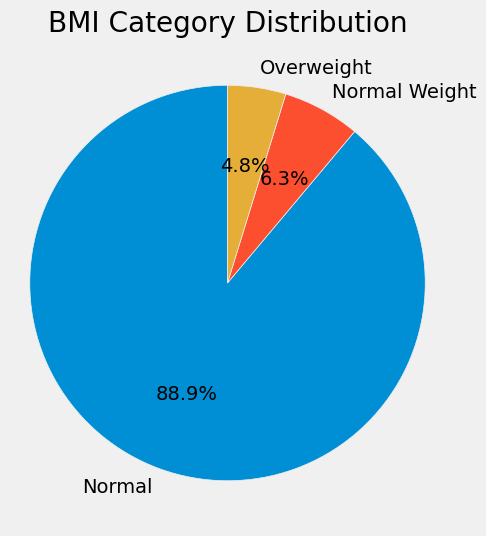

In [ ]:
pie_tbl_2 = tbl_engineer.group('BMI Category')
labels_2 = pie_tbl_2.column('BMI Category')
sizes_2  = pie_tbl_2.column('count')

# Used ChatGPT to help me make this pie chart
plots.figure(figsize=(5,6))
plots.pie(
    sizes_2,
    labels=labels_2,
    autopct='%1.1f%%',   # show percentages
    startangle=90        # rotate so first slice is at 12 o’clock
)
plots.title('BMI Category Distribution')
plots.axis('equal')        # ensure circle shape
plots.show()

### **Q7.** Next data insight involves exploring the gender makeup, ages, and lifestyle habits of Sales Representative, Salesperson, and Scientist (the Top 3 most stressed occupations)

In [ ]:
tbl_sales = tbl.where('Occupation','Sales Representative').select('Quality of Sleep','Age','Gender','Stress Level', 'Physical Activity Level','BMI Category','Daily Steps')
tbl_sales.group('BMI Category', np.average)

BMI Category,Quality of Sleep average,Age average,Gender average,Stress Level average,Physical Activity Level average,Daily Steps average
Obese,4,28,,8,30,3000


In [ ]:
tbl_sales_2 = tbl.where('Occupation','Salesperson').select('Quality of Sleep','Age','Gender','Stress Level', 'Physical Activity Level','BMI Category','Daily Steps')
tbl_sales_2.group('BMI Category')

BMI Category,count
Overweight,32


In [77]:
tbl_scientist = tbl.where('Occupation','Scientist').select('Quality of Sleep','Age','Gender','Stress Level', 'Physical Activity Level','BMI Category','Daily Steps')
tbl_scientist

Quality of Sleep,Age,Gender,Stress Level,Physical Activity Level,BMI Category,Daily Steps
6,33,Female,6,50,Overweight,5500
6,33,Female,6,50,Overweight,5500
4,34,Female,8,32,Overweight,5200
4,34,Female,8,32,Overweight,5200


In [ ]:
tbl_sales.num_rows + tbl_sales_2.num_rows + tbl_scientist.num_rows

38

### **Q8.** Next data insight involves exploring the relationship between Physical Activity Level and Stress Level with a Permutation Test.

In [ ]:
tbl.labels

('Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder')

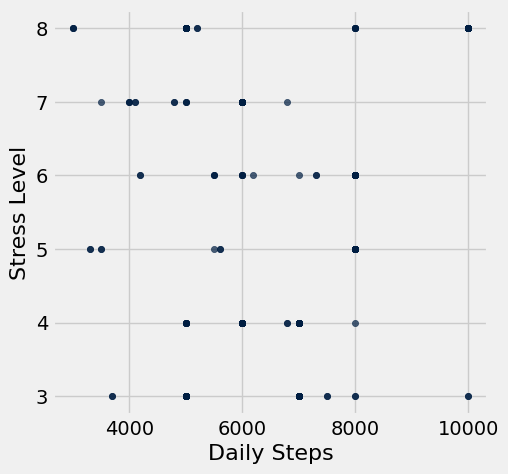

In [ ]:
tbl.select('Stress Level','Daily Steps').scatter('Daily Steps')

In [ ]:
correlation_matrix = np.corrcoef(tbl.column('Stress Level'),tbl.column('Daily Steps'))
correlation_coefficient = correlation_matrix[0, 1]
correlation_coefficient

0.18682895445881895

In [ ]:
def get_cor(table, var1, var2):
    """
    table: name of table,
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    return: correlation coefficient as a numeric value"""
    correlation_matrix = np.corrcoef(table.column(var1),table.column(var2))
    my_result = correlation_matrix[0, 1]
    return my_result

In [ ]:
def one_simulated_cor(table, var1, var2):
    """
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    Returns: correlation between two variables after shuffling"""
    shuffled_var2 = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled var2', shuffled_var2)
    return get_cor(shuffled_table, var1, 'Shuffled var2')

In [ ]:
observed_correlation = get_cor(tbl,'Stress Level', 'Daily Steps') # update
observed_correlation

0.18682895445881895

In [ ]:
cor_list = make_array()
for i in np.arange(100):
    new_cor = one_simulated_cor(tbl, 'Stress Level', 'Daily Steps') # update
    cor_list= np.append(cor_list, new_cor)
cor_list

array([ 0.03574048, -0.0363487 ,  0.04377114, -0.01384418,  0.04162341,
        0.03592724,  0.03172515, -0.02981212, -0.03989713,  0.00193701,
        0.01183526, -0.02383581,  0.06627567, -0.0354149 , -0.04904835,
        0.04096975,  0.07570703,  0.00959415, -0.05147622, -0.04195149,
        0.0536694 ,  0.07701434,  0.05357602,  0.04694606,  0.02789658,
       -0.03158633,  0.03667428,  0.07944222, -0.11506785, -0.03924347,
       -0.11095914, -0.05577169,  0.05647079,  0.13369586, -0.03298703,
       -0.0441926 ,  0.01407638,  0.01062132, -0.1088114 , -0.01524487,
       -0.06296194,  0.03163177, -0.01991386, -0.02775776,  0.08569866,
        0.01585059,  0.03247219, -0.05194312,  0.02070634,  0.05348264,
        0.01174188, -0.01449783, -0.06044068,  0.013983  , -0.01113616,
       -0.02504975,  0.00193701, -0.13943997, -0.05726577,  0.02995094,
       -0.02476961,  0.10726939, -0.05791943, -0.04344556,  0.00268404,
       -0.04531316, -0.01617867, -0.00114453, -0.0100156 ,  0.01

Observed correlation: 0.186828954459
p-value= 0.0


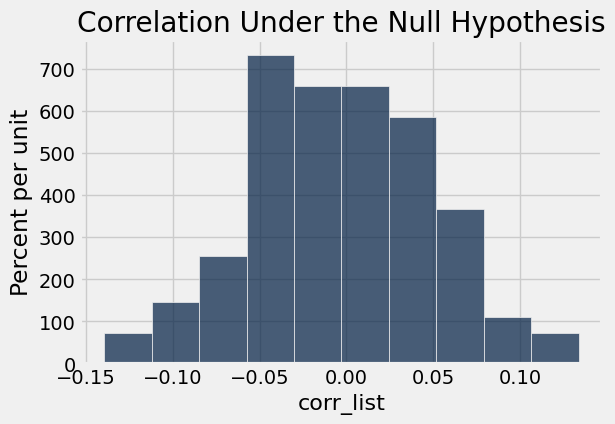

In [ ]:
Table().with_column('corr_list', cor_list).hist()
print('Observed correlation:',observed_correlation)
print('p-value=',np.mean(cor_list>observed_correlation)) # update: change the sign < or > to according to your problem
plots.title('Correlation Under the Null Hypothesis');